In [1]:
import numpy as np
import pandas as pd
import re

In [2]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv('..\data\processed\gurgaon_properties.csv')

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.head(1)
# focus is on -> areaWithType, additionalRoom, agePossession, furnishDetails, features 

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,3 BHK Flat in Sector 107 Gurgaon,flat,signature global solera,0.5,7751.0,645.0,Carpet area: 645 (59.92 sq.m.),3,2,2,others,"Sector 107 Gurgaon, Gurgaon, Haryana",6.0,South-East,1 to 5 Year Old,"['Gurgaon Dreamz Mall', 'Dwarka Expressway', ""Colonel's Central Academy"", 'The NorthCap University', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Trident Hotel Gurgaon', 'Fun N Food Village', 'DLF Golf and Country Club', 'F9 Go Karting Gurgaon', 'SkyJumper Trampoline Park Gurgaon']","This beautiful 3 bhk flat in sector 107 gurgaon is situated in signature global solera, one of the popular residential society in gurgaon. Constructed on a carpet area of 645 sq.Ft., the flat comprises 3 bedroom(s), 2 bathrooms and 2 balconies. The residential building has 14 floors in total and the flat for sale is located on the 6th floor. Being a ready to move project, you can expect immediate possession of this 1-5 years old property.\r\n Additional details :The apartment has borings water supply.\r\nDaily needs shopping could be done within the society premises to make the stay convinent.\r\nFull power backup is available.\r\nThe society has dedicated security guards for every tower.",NaN,"['Intercom Facility', 'Lift(s)', 'Park']","['Green Area4.5 out of 5', 'Construction4.5 out of 5', 'Management4 out of 5', 'Amenities4 out of 5', 'Connectivity3 out of 5']"


## 1. areaWithType

In [8]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
1207,NaN,NaN,Super Built up area 2100(195.1 sq.m.)
953,NaN,NaN,Super Built up area 1215(112.88 sq.m.)
531,0.94,1550.0,Carpet area: 1550 (144 sq.m.)
367,NaN,NaN,Carpet area: 1600 (148.64 sq.m.)
962,0.91,1326.0,Carpet area: 1326 (123.19 sq.m.)


In [9]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [10]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [11]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [12]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [13]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3741,0.32,house,565.0,Built Up area: 565 (52.49 sq.m.),NaN,565.0,NaN
1837,NaN,flat,NaN,Carpet area: 900 (83.61 sq.m.),NaN,NaN,900.0
3346,NaN,flat,NaN,Super Built up area 2660(247.12 sq.m.)Carpet area: 2354 sq.ft. (218.69 sq.m.),2660.0,NaN,2354.0
216,0.71,flat,1439.0,Carpet area: 1436 (133.41 sq.m.),NaN,NaN,1436.0
3671,2.40,house,242.0,Plot area 242(22.48 sq.m.),NaN,NaN,NaN


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(537, 7)

In [16]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
5,10.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
23,0.65,house,1125.0,Plot area 1125(104.52 sq.m.),NaN,NaN,NaN
30,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,NaN,NaN
33,1.50,house,1980.0,Plot area 220(183.95 sq.m.),NaN,NaN,NaN
54,26.00,house,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 sq.yards (334.45 sq.m.)Carpet area: 350 sq.yards (292.64 sq.m.),NaN,400.0,350.0


In [17]:
df.isnull().sum()

property_name             0
property_type             0
society                   1
price                  2094
price_per_sqft           20
area                   2094
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
address                  11
floorNum                 21
facing                 1177
agePossession             1
nearbyLocations         207
description               0
furnishDetails         1032
features                709
rating                  450
super_built_up_area    2027
built_up_area          2728
carpet_area            1958
dtype: int64

In [18]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [19]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
5,10.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
23,0.65,house,1125.0,Plot area 1125(104.52 sq.m.),NaN,NaN,NaN
30,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,NaN,NaN
33,1.50,house,1980.0,Plot area 220(183.95 sq.m.),NaN,NaN,NaN
55,4.50,house,1350.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN


In [20]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [21]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [22]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

# Update the original dataframe
#gurgaon_properties.update(filtered_rows)

In [23]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
5,10.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
23,0.65,house,1125.0,Plot area 1125(104.52 sq.m.),NaN,1125.00,NaN
30,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,161.00,NaN
33,1.50,house,1980.0,Plot area 220(183.95 sq.m.),NaN,220.00,NaN
55,4.50,house,1350.0,Plot area 150(125.42 sq.m.),NaN,150.00,NaN
67,4.75,house,5067.0,Plot area 563(470.74 sq.m.),NaN,563.00,NaN
71,NaN,house,NaN,Plot area 50(41.81 sq.m.),NaN,50.00,NaN
75,11.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
84,5.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,200.00,NaN
87,4.00,house,2400.0,Plot area 2400(222.97 sq.m.),NaN,2400.00,NaN


In [24]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [25]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [26]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
5,10.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
23,0.65,house,1125.0,Plot area 1125(104.52 sq.m.),NaN,1125.00,NaN
30,3.60,house,1449.0,Plot area 161(134.62 sq.m.),NaN,1449.00,NaN
33,1.50,house,1980.0,Plot area 220(183.95 sq.m.),NaN,1980.00,NaN
55,4.50,house,1350.0,Plot area 150(125.42 sq.m.),NaN,1350.00,NaN
67,4.75,house,5067.0,Plot area 563(470.74 sq.m.),NaN,5067.00,NaN
71,NaN,house,NaN,Plot area 50(41.81 sq.m.),NaN,50.00,NaN
75,11.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
84,5.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,1800.00,NaN
87,4.00,house,2400.0,Plot area 2400(222.97 sq.m.),NaN,2400.00,NaN


In [27]:
# update the original dataframe
df.update(all_nan_df)

In [28]:
df.isnull().sum()

property_name             0
property_type             0
society                   1
price                  2094
price_per_sqft           20
area                   2094
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
address                  11
floorNum                 21
facing                 1177
agePossession             1
nearbyLocations         207
description               0
furnishDetails         1032
features                709
rating                  450
super_built_up_area    2027
built_up_area          2113
carpet_area            1958
dtype: int64

In [29]:
df.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,super_built_up_area,built_up_area,carpet_area
0,3 BHK Flat in Sector 107 Gurgaon,flat,signature global solera,0.50,7751.0,645.0,Carpet area: 645 (59.92 sq.m.),3,2,2,others,"Sector 107 Gurgaon, Gurgaon, Haryana",6.0,South-East,1 to 5 Year Old,"['Gurgaon Dreamz Mall', 'Dwarka Expressway', ""Colonel's Central Academy"", 'The NorthCap University', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Trident Hotel Gurgaon', 'Fun N Food Village', 'DLF Golf and Country Club', 'F9 Go Karting Gurgaon', 'SkyJumper Trampoline Park Gurgaon']","This beautiful 3 bhk flat in sector 107 gurgaon is situated in signature global solera, one of the popular residential society in gurgaon. Constructed on a carpet area of 645 sq.Ft., the flat comprises 3 bedroom(s), 2 bathrooms and 2 balconies. The residential building has 14 floors in total and the flat for sale is located on the 6th floor. Being a ready to move project, you can expect immediate possession of this 1-5 years old property.\r\n Additional details :The apartment has borings water supply.\r\nDaily needs shopping could be done within the society premises to make the stay convinent.\r\nFull power backup is available.\r\nThe society has dedicated security guards for every tower.",NaN,"['Intercom Facility', 'Lift(s)', 'Park']","['Green Area4.5 out of 5', 'Construction4.5 out of 5', 'Management4 out of 5', 'Amenities4 out of 5', 'Connectivity3 out of 5']",NaN,NaN,645.00
1,2 BHK Flat in Sector 95 Gurgaon,flat,sidhartha ncr greens,0.56,5656.0,990.0,Super Built up area 990(91.97 sq.m.),2,2,3,not available,"Sector 95 Gurgaon, Gurgaon, Haryana",13.0,NaN,0 to 1 Year Old,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. Sarkar Clinic', 'Vijay Petrol Pump']","Residential apartment for sell.The property comes with a good construction quality which age 0-1 year old property located in sector 95,gurgaon",[],"['Power Back-up', 'Lift(s)', 'Park', 'Piped-gas']","['Green Area4 out of 5', 'Construction5 out of 5', 'Management4 out of 5', 'Amenities5 out of 5', 'Connectivity4 out of 5']",990.0,NaN,NaN
2,3 BHK Flat in Sector 63 Gurgaon,flat,adani brahma samsara vilasa,NaN,16666.0,NaN,Carpet area: 1800 (167.23 sq.m.),3,3,3,not available,"Sector 63 Gurgaon, Gurgaon, Haryana",3.0,East,0 to 1 Year Old,"['Rapid Metro Station Sector 56', 'Paras Trinity Mall Sector 63', 'Golf Course Ext Rd', 'Mehrauli-Gurgaon Road', 'Nirvana Rd', 'Heritage Xperiential Learning School', 'KIIT College of Engineering Sohna Road', 'CK Birla Hospital', 'Indira Gandhi International Airport', 'AIPL Business Club Sector 62', 'DoubleTree by Hilton Hotel Gurgaon', 'De Adventure Park', 'TERI Golf Course']",New construction. Ready to move. Park facing unit,"['1 Fan', '1 Light', '1 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Lift(s)', 'Park', 'Piped-gas', 'Natural Light', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,NaN,NaN,1800.00
3,3 BHK Flat in Sector 83 Gurgaon,flat,emaar palm gardens,NaN,9263.0,NaN,Super Built up area 1900(176.52 sq.m.)Built Up area: 1600 sq.ft. (148.64 sq.m.)Carpet area: 1240.04 sq.ft. (115.2 sq.m.),3,3,3,servant room,"806, Sector 83 Gurgaon, Gurgaon, Haryana",5.0,South-East,1 to 5 Year Old,"[""V'Lante Mall"", 'NH 48 Gurugram', 'iGrow Montessori Play School', 'Matrikiran High School', 'Badsa AMS Hospital', 'GlobalHealthcare Multispeciality', 'Indira Gandhi International Airport', 'Patli Railway Station', 'Hyatt Regency', 'Nakhrola Stadium', 'Cricket Academy']","This 3 bhk flat is located in emaar palm gardens, which houses some of the most spacious flats in sector 83 gurgaon. This is a north-Facing prope

## 2.additionalRoom

In [30]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1691
servant room                                      710
study room                                        251
others                                            237
pooja room                                        170
store room                                        107
study room,servant room                           100
pooja room,servant room                            84
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 57
pooja room,study room,servant room,others          57
servant room,pooja room                            38
servant room,store room                            34
study room,others                                  30
pooja room,study room                              24
pooja room,others                                  17
pooja room,store room                              17
servant room,

In [31]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [32]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
2966,store room,0,0,1,0,0
3650,"pooja room,study room,servant room,others",1,1,0,1,1
1678,servant room,0,1,0,0,0
3111,study room,1,0,0,0,0
3759,"others,study room",1,0,0,0,1


In [33]:
df.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,3 BHK Flat in Sector 107 Gurgaon,flat,signature global solera,0.50,7751.0,645.0,Carpet area: 645 (59.92 sq.m.),3,2,2,others,"Sector 107 Gurgaon, Gurgaon, Haryana",6.0,South-East,1 to 5 Year Old,"['Gurgaon Dreamz Mall', 'Dwarka Expressway', ""Colonel's Central Academy"", 'The NorthCap University', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Trident Hotel Gurgaon', 'Fun N Food Village', 'DLF Golf and Country Club', 'F9 Go Karting Gurgaon', 'SkyJumper Trampoline Park Gurgaon']","This beautiful 3 bhk flat in sector 107 gurgaon is situated in signature global solera, one of the popular residential society in gurgaon. Constructed on a carpet area of 645 sq.Ft., the flat comprises 3 bedroom(s), 2 bathrooms and 2 balconies. The residential building has 14 floors in total and the flat for sale is located on the 6th floor. Being a ready to move project, you can expect immediate possession of this 1-5 years old property.\r\n Additional details :The apartment has borings water supply.\r\nDaily needs shopping could be done within the society premises to make the stay convinent.\r\nFull power backup is available.\r\nThe society has dedicated security guards for every tower.",NaN,"['Intercom Facility', 'Lift(s)', 'Park']","['Green Area4.5 out of 5', 'Construction4.5 out of 5', 'Management4 out of 5', 'Amenities4 out of 5', 'Connectivity3 out of 5']",NaN,NaN,645.00,0,0,0,0,1
1,2 BHK Flat in Sector 95 Gurgaon,flat,sidhartha ncr greens,0.56,5656.0,990.0,Super Built up area 990(91.97 sq.m.),2,2,3,not available,"Sector 95 Gurgaon, Gurgaon, Haryana",13.0,NaN,0 to 1 Year Old,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. Sarkar Clinic', 'Vijay Petrol Pump']","Residential apartment for sell.The property comes with a good construction quality which age 0-1 year old property located in sector 95,gurgaon",[],"['Power Back-up', 'Lift(s)', 'Park', 'Piped-gas']","['Green Area4 out of 5', 'Construction5 out of 5', 'Management4 out of 5', 'Amenities5 out of 5', 'Connectivity4 out of 5']",990.0,NaN,NaN,0,0,0,0,0
2,3 BHK Flat in Sector 63 Gurgaon,flat,adani brahma samsara vilasa,NaN,16666.0,NaN,Carpet area: 1800 (167.23 sq.m.),3,3,3,not available,"Sector 63 Gurgaon, Gurgaon, Haryana",3.0,East,0 to 1 Year Old,"['Rapid Metro Station Sector 56', 'Paras Trinity Mall Sector 63', 'Golf Course Ext Rd', 'Mehrauli-Gurgaon Road', 'Nirvana Rd', 'Heritage Xperiential Learning School', 'KIIT College of Engineering Sohna Road', 'CK Birla Hospital', 'Indira Gandhi International Airport', 'AIPL Business Club Sector 62', 'DoubleTree by Hilton Hotel Gurgaon', 'De Adventure Park', 'TERI Golf Course']",New construction. Ready to move. Park facing unit,"['1 Fan', '1 Light', '1 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Lift(s)', 'Park', 'Piped-gas', 'Natural Light', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,NaN,NaN,1800.00,0,0,0,0,0
3,3 BHK Flat in Sector 83 Gurgaon,flat,emaar palm gardens,NaN,9263.0,NaN,Super Built up area 1900(176.52 sq.m.)Built Up area: 1600 sq.ft. (148.64 sq.m.)Carpet area: 1240.04 sq.ft. (115.2 sq.m.),3,3,3,servant room,"806, Sector 83 Gurgaon, Gurgaon, Haryana",5.0,South-East,1 to 5 Year Old,"[""V'Lante Mall"", 'NH 48 Gurugram', 'iGrow Montessori Play School', 'Matrikiran High School', 'Badsa AMS Hospital', 'GlobalHealthcare Multispeciality', 'Indira Gandhi International Airport', 'Patli Railway Station', 'Hyatt Regency', 'Nakhrola Stadium', 'Cricket Academy']","This 3 bhk flat is located in emaar palm gardens, which houses

## 3.agePossession

In [34]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1705
5 to 10 Year Old       610
0 to 1 Year Old        551
undefined              358
10+ Year Old           353
Under Construction      92
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Jan 2024                 8
Oct 2024                 8
Jun 2024                 7
Dec 2025                 7
Aug 2023                 7
Nov 2023                 5
Aug 2024                 5
Oct 2023                 4
Jul 2024                 4
By 2025                  4
Jan 2025                 4
Sep 2023                 4
Nov 2024                 3
May 2024                 3
Feb 2024                 3
Jul 2027                 2
Apr 2026                 2
Jan 2026                 2
Sep 2025                 2
Aug 2025                 2
Mar 2025                 2
By 2027                  2
Jun 2027                 2
Dec 2026      

In [35]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [36]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [37]:
df['agePossession'].value_counts()

agePossession
Relatively New        1705
New Property           647
Moderately Old         610
Undefined              359
Old Property           353
Under Construction     287
Name: count, dtype: int64

In [38]:
df.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,3 BHK Flat in Sector 107 Gurgaon,flat,signature global solera,0.50,7751.0,645.0,Carpet area: 645 (59.92 sq.m.),3,2,2,others,"Sector 107 Gurgaon, Gurgaon, Haryana",6.0,South-East,Relatively New,"['Gurgaon Dreamz Mall', 'Dwarka Expressway', ""Colonel's Central Academy"", 'The NorthCap University', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Trident Hotel Gurgaon', 'Fun N Food Village', 'DLF Golf and Country Club', 'F9 Go Karting Gurgaon', 'SkyJumper Trampoline Park Gurgaon']","This beautiful 3 bhk flat in sector 107 gurgaon is situated in signature global solera, one of the popular residential society in gurgaon. Constructed on a carpet area of 645 sq.Ft., the flat comprises 3 bedroom(s), 2 bathrooms and 2 balconies. The residential building has 14 floors in total and the flat for sale is located on the 6th floor. Being a ready to move project, you can expect immediate possession of this 1-5 years old property.\r\n Additional details :The apartment has borings water supply.\r\nDaily needs shopping could be done within the society premises to make the stay convinent.\r\nFull power backup is available.\r\nThe society has dedicated security guards for every tower.",NaN,"['Intercom Facility', 'Lift(s)', 'Park']","['Green Area4.5 out of 5', 'Construction4.5 out of 5', 'Management4 out of 5', 'Amenities4 out of 5', 'Connectivity3 out of 5']",NaN,NaN,645.00,0,0,0,0,1
1,2 BHK Flat in Sector 95 Gurgaon,flat,sidhartha ncr greens,0.56,5656.0,990.0,Super Built up area 990(91.97 sq.m.),2,2,3,not available,"Sector 95 Gurgaon, Gurgaon, Haryana",13.0,NaN,New Property,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. Sarkar Clinic', 'Vijay Petrol Pump']","Residential apartment for sell.The property comes with a good construction quality which age 0-1 year old property located in sector 95,gurgaon",[],"['Power Back-up', 'Lift(s)', 'Park', 'Piped-gas']","['Green Area4 out of 5', 'Construction5 out of 5', 'Management4 out of 5', 'Amenities5 out of 5', 'Connectivity4 out of 5']",990.0,NaN,NaN,0,0,0,0,0
2,3 BHK Flat in Sector 63 Gurgaon,flat,adani brahma samsara vilasa,NaN,16666.0,NaN,Carpet area: 1800 (167.23 sq.m.),3,3,3,not available,"Sector 63 Gurgaon, Gurgaon, Haryana",3.0,East,New Property,"['Rapid Metro Station Sector 56', 'Paras Trinity Mall Sector 63', 'Golf Course Ext Rd', 'Mehrauli-Gurgaon Road', 'Nirvana Rd', 'Heritage Xperiential Learning School', 'KIIT College of Engineering Sohna Road', 'CK Birla Hospital', 'Indira Gandhi International Airport', 'AIPL Business Club Sector 62', 'DoubleTree by Hilton Hotel Gurgaon', 'De Adventure Park', 'TERI Golf Course']",New construction. Ready to move. Park facing unit,"['1 Fan', '1 Light', '1 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Lift(s)', 'Park', 'Piped-gas', 'Natural Light', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,NaN,NaN,1800.00,0,0,0,0,0
3,3 BHK Flat in Sector 83 Gurgaon,flat,emaar palm gardens,NaN,9263.0,NaN,Super Built up area 1900(176.52 sq.m.)Built Up area: 1600 sq.ft. (148.64 sq.m.)Carpet area: 1240.04 sq.ft. (115.2 sq.m.),3,3,3,servant room,"806, Sector 83 Gurgaon, Gurgaon, Haryana",5.0,South-East,Relatively New,"[""V'Lante Mall"", 'NH 48 Gurugram', 'iGrow Montessori Play School', 'Matrikiran High School', 'Badsa AMS Hospital', 'GlobalHealthcare Multispeciality', 'Indira Gandhi International Airport', 'Patli Railway Station', 'Hyatt Regency', 'Nakhrola Stadium', 'Cricket Academy']","This 3 bhk flat is located in emaar palm gardens, which houses some of

## 4.furnishDetails

In [39]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
3909,NaN,"['Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Separate entry for servant room', 'Park', 'Security Personnel', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Waste Disposal', 'Water softening plant']"
126,"['6 Fan', '1 Exhaust Fan', '21 Light', '5 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
3799,"['1 Geyser', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
722,NaN,['Private Garden / Terrace']
2043,"['5 Wardrobe', '1 Exhaust Fan', '1 Stove', '50 Light', '15 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [40]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]


In [41]:
furnishings_df.shape

(3961, 19)

In [42]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\vyash\AppData\Local\Temp\ipykernel_8172\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [43]:
furnishings_df.sample(5)

,Fan,TV,Water Purifier,Bed,Exhaust Fan,Dining Table,Washing Machine,Stove,Curtains,Light,Microwave,Chimney,Sofa,Wardrobe,Modular Kitchen,Geyser,Fridge,AC
2012,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
398,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1010,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3030,5,0,0,0,1,0,0,0,0,5,0,1,0,0,1,3,0,0
3163,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [44]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [45]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [46]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

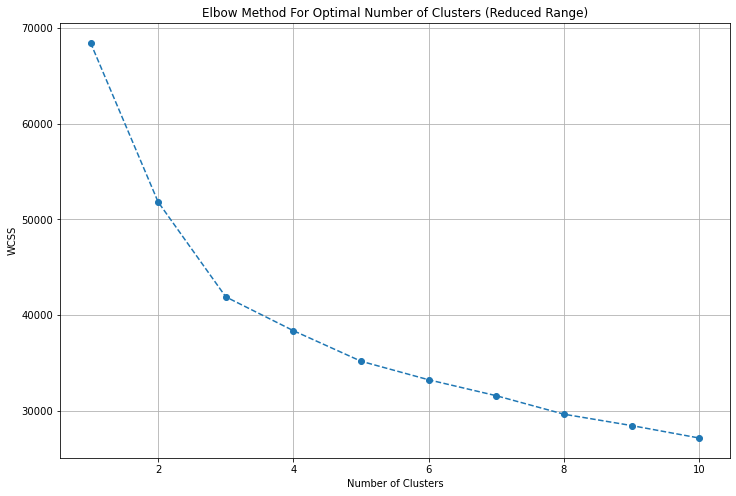

In [614]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [47]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [48]:
df = df.iloc[:,:-18]

In [49]:
df['furnishing_type'] = cluster_assignments

In [50]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
2158,"['3 Wardrobe', '3 Fan', '1 Exhaust Fan', '3 Geyser', '9 Light', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",2
2734,"['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '2 Geyser', '11 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",2
3154,NaN,0
914,[],0
2702,"['8 Fan', '1 Exhaust Fan', '3 Geyser', '12 Light', '4 TV', '1 Chimney', '5 AC', '1 Modular Kitchen', '1 Curtains', '3 Bed', '3 Wardrobe', '1 Sofa', '1 Microwave', 'No Dining Table', 'No Fridge', 'No Stove', 'No Washing Machine', 'No Water Purifier']",1


## 5.features

In [51]:
df[['society','features']].sample(5)

,society,features
1460,eldeco accolade,"['Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"
2717,emaar mgf the palm drive,"['Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
1698,mapsko mount ville,"['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Internet/wi-fi connectivity', 'Low Density Society', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
3447,signature global the millennia,"['Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Bank Attached Property', 'Visitor Parking', 'Park', 'Security Personnel', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"
1519,sidhartha ncr one,NaN


In [52]:
df['features'].isnull().sum()

np.int64(709)

In [57]:
import pandas as pd
app_df = pd.read_csv(r'C:\Projects\House Prediction\data\raw\appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [58]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [59]:
temp_df = df[df['features'].isnull()]

In [ ]:
temp_df.shape

(709, 29)

In [61]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [62]:
df.loc[temp_df.index,'features'] = x.values

In [63]:
df['features'].isnull().sum()

np.int64(552)

In [64]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [65]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [66]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
3599,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0
2509,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
564,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
705,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3924,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [67]:
features_binary_df.shape

(3961, 130)

In [68]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

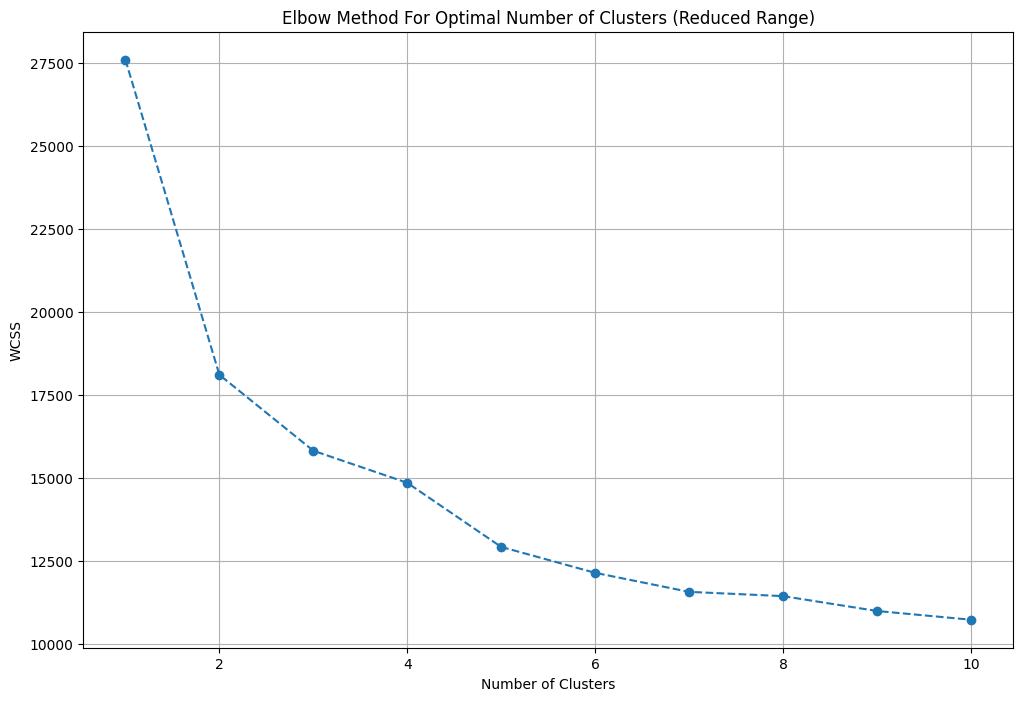

In [69]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [70]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)


In [71]:
df['luxury_score'] = luxury_score

In [72]:
df.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,3 BHK Flat in Sector 107 Gurgaon,flat,signature global solera,0.50,7751.0,645.0,Carpet area: 645 (59.92 sq.m.),3,2,2,others,"Sector 107 Gurgaon, Gurgaon, Haryana",6.0,South-East,Relatively New,"['Gurgaon Dreamz Mall', 'Dwarka Expressway', ""Colonel's Central Academy"", 'The NorthCap University', 'Chirag Hospital', 'Indira Gandhi International Airport', 'Trident Hotel Gurgaon', 'Fun N Food Village', 'DLF Golf and Country Club', 'F9 Go Karting Gurgaon', 'SkyJumper Trampoline Park Gurgaon']","This beautiful 3 bhk flat in sector 107 gurgaon is situated in signature global solera, one of the popular residential society in gurgaon. Constructed on a carpet area of 645 sq.Ft., the flat comprises 3 bedroom(s), 2 bathrooms and 2 balconies. The residential building has 14 floors in total and the flat for sale is located on the 6th floor. Being a ready to move project, you can expect immediate possession of this 1-5 years old property.\r\n Additional details :The apartment has borings water supply.\r\nDaily needs shopping could be done within the society premises to make the stay convinent.\r\nFull power backup is available.\r\nThe society has dedicated security guards for every tower.",NaN,"['Intercom Facility', 'Lift(s)', 'Park']","['Green Area4.5 out of 5', 'Construction4.5 out of 5', 'Management4 out of 5', 'Amenities4 out of 5', 'Connectivity3 out of 5']",NaN,NaN,645.00,0,0,0,0,1,0,"[Intercom Facility, Lift(s), Park]",15
1,2 BHK Flat in Sector 95 Gurgaon,flat,sidhartha ncr greens,0.56,5656.0,990.0,Super Built up area 990(91.97 sq.m.),2,2,3,not available,"Sector 95 Gurgaon, Gurgaon, Haryana",13.0,NaN,New Property,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. Sarkar Clinic', 'Vijay Petrol Pump']","Residential apartment for sell.The property comes with a good construction quality which age 0-1 year old property located in sector 95,gurgaon",[],"['Power Back-up', 'Lift(s)', 'Park', 'Piped-gas']","['Green Area4 out of 5', 'Construction5 out of 5', 'Management4 out of 5', 'Amenities5 out of 5', 'Connectivity4 out of 5']",990.0,NaN,NaN,0,0,0,0,0,0,"[Power Back-up, Lift(s), Park, Piped-gas]",8
2,3 BHK Flat in Sector 63 Gurgaon,flat,adani brahma samsara vilasa,NaN,16666.0,NaN,Carpet area: 1800 (167.23 sq.m.),3,3,3,not available,"Sector 63 Gurgaon, Gurgaon, Haryana",3.0,East,New Property,"['Rapid Metro Station Sector 56', 'Paras Trinity Mall Sector 63', 'Golf Course Ext Rd', 'Mehrauli-Gurgaon Road', 'Nirvana Rd', 'Heritage Xperiential Learning School', 'KIIT College of Engineering Sohna Road', 'CK Birla Hospital', 'Indira Gandhi International Airport', 'AIPL Business Club Sector 62', 'DoubleTree by Hilton Hotel Gurgaon', 'De Adventure Park', 'TERI Golf Course']",New construction. Ready to move. Park facing unit,"['1 Fan', '1 Light', '1 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Lift(s)', 'Park', 'Piped-gas', 'Natural Light', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,NaN,NaN,1800.00,0,0,0,0,0,0,"[Lift(s), Park, Piped-gas, Natural Light, Fitness Centre / GYM, Club house / Community Center]",24
3,3 BHK Flat in Sector 83 Gurgaon,flat,emaar palm gardens,NaN,9263.0,NaN,Super Built up area 1900(176.52 sq.m.)Built Up area: 1600 sq.ft. (148.64 sq.m.)Carpet area: 1240.04 sq.ft. (115.2 sq.m.),3,3,3,servant room,"806, Sector 83 Gurgaon, Gurgaon, Haryana",5.0,South-East,Relatively New,"[""V'Lante Mall"", 'NH 48 Gurugram', 'iGrow Montessori Play School', 'Matrikiran High School', 'Badsa AMS Hosp

In [73]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [74]:
df.sample(5)

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,rating,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1766,1 BHK Flat in Sector 95 Gurgaon,flat,rof ananda,0.21,61.0,34426.0,Carpet area: 34401 (3195.96 sq.m.),1,1,1,"Sector 95 Gurgaon, Gurgaon, Haryana",13.0,North,Relatively New,"Ambitious, personable agent with 15 years of experience providing\r\nExtensive knowledge about the real estate community and housing\r\nMarket. Eager to continue growing in market trends while proving my\r\nAbility to win clients, guiding them through inception to close, who\r\nWill refer future business to opendoor.\r\n Additional details :Daily needs shopping could be done within the society premises to make the stay convinent.\r\nNo power backup is available.","['Environment4 out of 5', 'Lifestyle4.5 out of 5', 'Connectivity4 out of 5', 'Safety4.5 out of 5']",NaN,NaN,34401.0,0,0,0,0,0,0,68
3294,4 Bedroom House for sale in Sector 48 Gurgaon,house,vipul tatvam villa,8.40,21000.0,4000.0,Plot area 4000(371.61 sq.m.),4,5,3+,"Sector 48 Gurgaon, Gurgaon, Haryana",2.0,North,Moderately Old,"Wishing to settle down in an individual house with your family? This well-Built and spacious 4 bhk house for sale in sector 48 gurgaon seems to be an ideal choice for a peaceful abode for a family. The floor plan additionally contains 4 bedrooms, 5 bathrooms and more than 3 balconies. All in all, the independent house is spread over a super built up area of 4000 sq.Ft. There are 2 covered & 3 open parking available with this house. This is a ready to move house, which is 5-10 years old. The ownership right of this property is freehold. The property is available for sale at a competitive price of 8.4 crore.","['Environment4 out of 5', 'Lifestyle4 out of 5', 'Connectivity5 out of 5', 'Safety4 out of 5']",NaN,4000.0,NaN,1,1,0,1,0,2,49
1821,3 BHK Flat in Sector 82 Gurgaon,flat,mapsko royale ville,0.99,5530.0,1790.0,Super Built up area 1790(166.3 sq.m.),3,4,2,"Sector 82, Sector 82 Gurgaon, Gurgaon, Haryana",14.0,South-West,New Property,"Immediate visit possible. Call 99999-82787 for visit growth realtech. For more info. Pls visit @ site address : Ab2-104, mapsko casa bella","['Green Area4.5 out of 5', 'Construction3 out of 5', 'Management3.5 out of 5', 'Amenities4 out of 5', 'Connectivity4 out of 5']",1790.0,NaN,NaN,0,1,0,0,0,0,95
2113,3 Bedroom House for sale in Laxman Vihar,house,independent,0.60,105263.0,57.0,Plot area 57(5.3 sq.m.),3,3,1,"Laxman Vihar, Gurgaon, Haryana",2.0,NaN,Old Property,Well maintained house.\r\n3 bedrooms \r\n2 kitchen \r\n3 bathrooms,"['Environment4 out of 5', 'Lifestyle4 out of 5', 'Connectivity5 out of 5', 'Safety4 out of 5']",NaN,57.0,NaN,0,0,0,0,1,0,0
1825,6 Bedroom House for sale in Sector 33 Gurgaon,house,unitech uniworld resorts,8.00,17778.0,4500.0,Built Up area: 500 (418.06 sq.m.),6,5,3+,"A 121 The Villas Uniworld Resorts, Sector 33 Gurgaon, Gurgaon, Haryana",4.0,NaN,Undefined,6bhk villa for resale in unitech the villas at sector 33 unitech the villas a 121 the villas uniworld resorts,"['Environment3 out of 5', 'Lifestyle4 out of 5', 'Connectivity4 out of 5', 'Safety4 out of 5']",NaN,500.0,NaN,0,0,0,0,0,0,0


In [75]:
df.shape

(3961, 26)

In [77]:
df.to_csv('..\data\processed\gurgaon_properties_cleaned_v2.csv',index=False)